In [16]:
import tensorflow as tf

In [17]:
x1 = tf.constant(5)
x2 = tf.constant(6)
x3 = tf.add(x1, x2)
x3.numpy()

np.int32(11)

In [18]:
v1 = tf.constant([1,2,3,4])
v2 = tf.constant([2,1,5,3])
v3 = v1 + v2
v3.numpy()

array([3, 3, 8, 7], dtype=int32)

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
data = pd.read_csv('FuelConsumptionCo2.csv')

In [21]:
data.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [22]:
x_d =data.loc[:,'ENGINESIZE'].values
y_d = data.loc[:,'CO2EMISSIONS'].values

In [23]:
x = tf.constant(x_d, dtype=tf.float32)   # Input features
y = tf.constant(y_d, dtype=tf.float32)   # Target values

In [24]:
w = tf.Variable(2.0, dtype=tf.float32)
b = tf.Variable(7.2, dtype=tf.float32)

In [25]:
def H(x): # Hypothesis function
  y_p =  w * x + b
  return y_p

In [26]:
def cost_function(y_actual, y_pred):
  mse = tf.reduce_mean(tf.square(y_actual - y_pred))  #1/M *sum((y_actual - y_hat))
  return mse

In [27]:
lr = 0.01
epochs = 1000
loss_values = []
for epoch in range(epochs):
  with tf.GradientTape() as t:
    y_pred = H(x)
    loss = cost_function(y, y_pred)
    loss_values.append(loss)
    gradient = t.gradient(loss, [w, b])
    w.assign_sub(lr * gradient[0])  #assign_sub is used to update the value of w and b by subtracting the product of learning rate and gradient from the current value of w and b
    b.assign_sub(lr * gradient[1])

In [28]:
loss

<tf.Tensor: shape=(), dtype=float32, numpy=951.5821533203125>

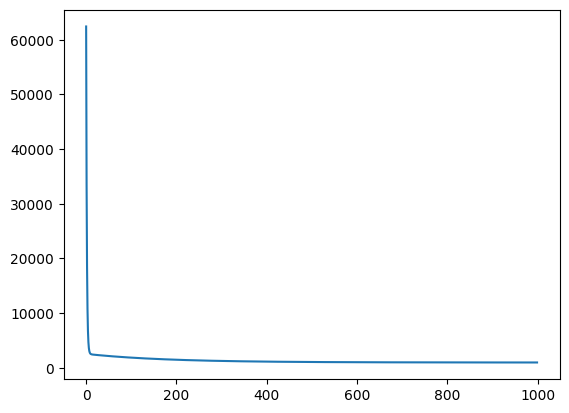

In [29]:
plt.plot(loss_values)
plt.show()

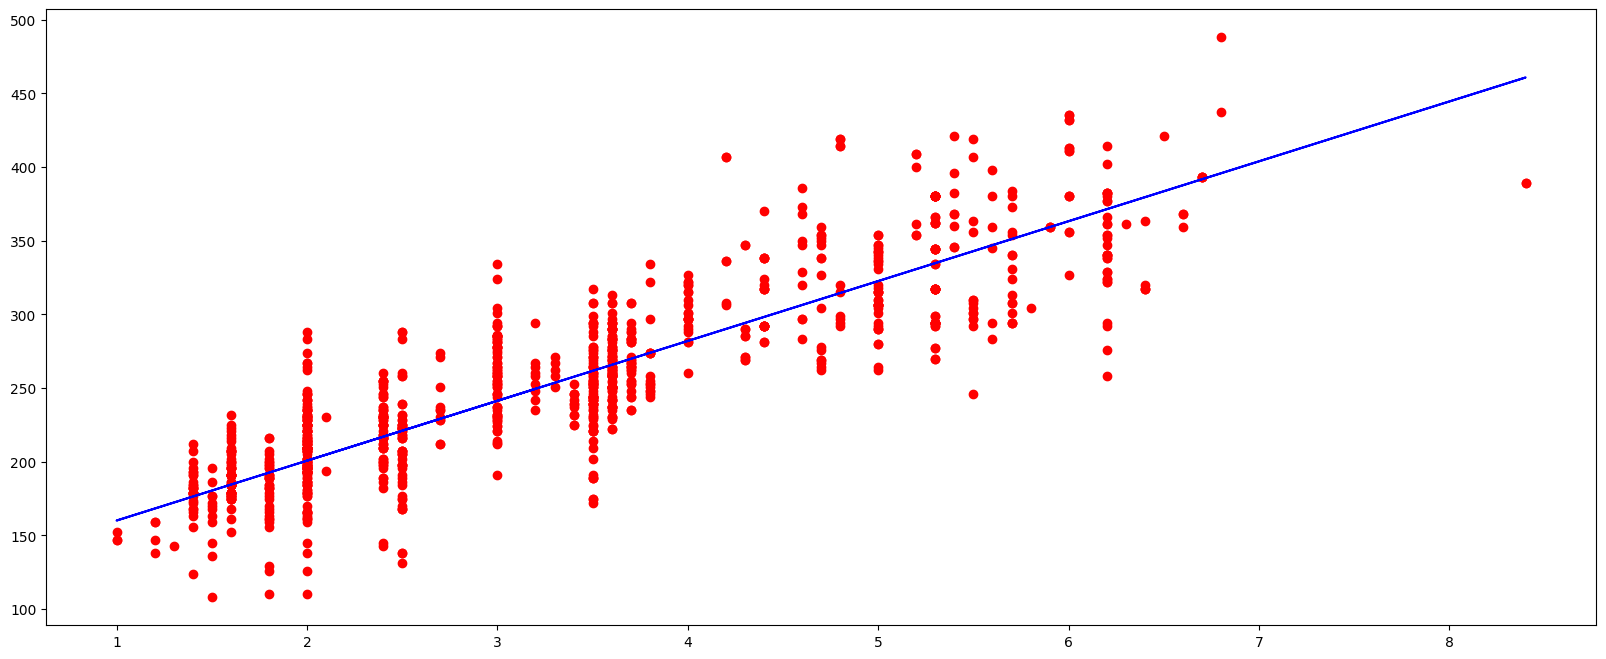

In [30]:
plt.figure(figsize=(20,8))
plt.scatter(x.numpy(), y.numpy(), color='red')
plt.plot(x.numpy(), H(x).numpy(), color='blue')
plt.show()

In [31]:
# Multilayer Perceptron
from keras.utils import plot_model
from keras.models import Model
from keras.layers import Input
from keras.layers import Dense #Dense = hiddel layer
visible = Input(shape=(10,))
hidden1 = Dense(500, activation='tanh')(visible) #layer-1
hidden2 = Dense(300, activation='tanh')(hidden1)
hidden3 = Dense(100, activation='tanh')(hidden2)
 
output = Dense(1, activation='sigmoid')(hidden3)  # as one Node in output layer
model = Model(inputs=visible, outputs=output)  # make the model understand that the model start from input to output
# summarize layers
print(model.summary()) 
#Param = (input+1) * output = (10+1) * 500 = 5500
# Non-trainable params: 0  this is the node i  have turnned it off by using activation function as tanh

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 500)            │         5,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 300)            │       150,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 186,001 (726.57 KB)

 Trainable params: 186,001 (726.57 KB)

 Non-trainable params: 0 (0.00 B)

None
